# Analytics KPI Explorer

This notebook connects to the analytics database through the shared ETL config and reads the KPI materialized views used by the analytics page.

KPIs covered:
- Top contributors
- Activity trends
- Posts per category


## Prerequisites

Before running this notebook:
1. The ETL pipeline should have loaded the warehouse and refreshed KPI materialized views.
2. `data-engineering/.env` must point to the analytics database.
3. Run the notebook from the `data-engineering` folder or from `data-engineering/notebooks`.


In [22]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / 'configs' / 'config.yml').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'configs' / 'config.yml').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR / 'data-engineering' / 'configs' / 'config.yml').exists():
    PROJECT_ROOT = CURRENT_DIR / 'data-engineering'
else:
    raise FileNotFoundError('Could not locate data-engineering/configs/config.yml from the current working directory.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from analytics.activity_trends import fetch_activity_trends
from analytics.posts_per_category import fetch_posts_per_category
from analytics.top_contributors import fetch_top_contributors
from utils.config_loader import load_config
from utils.database import get_db_config

plt.style.use('seaborn-v0_8-whitegrid')


In [23]:
config = load_config()
analytics_db = get_db_config(config, db_role='analytics')
warehouse_schema = config['warehouse']['schema']
kpi_views = config['warehouse']['kpis']['materialized_views']

connection_preview = {
    'host': analytics_db['host'],
    'port': analytics_db['port'],
    'database': analytics_db['database'],
    'user': analytics_db['user'],
    'schema': warehouse_schema,
    'materialized_views': kpi_views,
}
connection_preview


{'host': 'communityboard-db-public.cfuou2mwe5a1.eu-west-1.rds.amazonaws.com',
 'port': 5432,
 'database': 'communityboard',
 'user': 'postgres',
 'schema': 'analytics',
 'materialized_views': {'top_contributors': 'kpi_top_contributors_mv',
  'activity_trends': 'kpi_activity_trends_mv',
  'posts_per_category': 'kpi_posts_per_category_mv'}}

In [24]:
start_date = None  # Example: '2026-03-01'
end_date = None    # Example: '2026-03-31'
top_limit = 10


In [25]:
top_contributors_df = pd.DataFrame(
    fetch_top_contributors(
        config=config,
        limit=top_limit,
        start_date=start_date,
        end_date=end_date,
    )
)
activity_trends_df = pd.DataFrame(
    fetch_activity_trends(
        config=config,
        start_date=start_date,
        end_date=end_date,
    )
)
posts_per_category_df = pd.DataFrame(
    fetch_posts_per_category(
        config=config,
        start_date=start_date,
        end_date=end_date,
    )
)

if not activity_trends_df.empty:
    activity_trends_df['activity_date'] = pd.to_datetime(activity_trends_df['activity_date'])

top_contributors_df, activity_trends_df, posts_per_category_df


(   source_user_id full_name    role  post_count  comment_count  \
 0               1  Frimpong  member         150            231   
 1               9   Abraham  member           2              0   
 2              86      sage  member           1              0   
 3              87   harriee  member           0              1   
 
    total_contributions  
 0                  381  
 1                    2  
 2                    1  
 3                    1  ,
    activity_date  posts_count  comments_count  total_activity_count
 0     2026-02-11            2               0                     2
 1     2026-02-12            6               1                     7
 2     2026-02-13            6               2                     8
 3     2026-02-14            6               3                     9
 4     2026-02-15            2               1                     3
 5     2026-02-16           10               2                    12
 6     2026-02-17            6               2   

## Top Contributors


In [26]:
top_contributors_df


,source_user_id,full_name,role,post_count,comment_count,total_contributions
0,1,Frimpong,member,150,231,381
1,9,Abraham,member,2,0,2
2,86,sage,member,1,0,1
3,87,harriee,member,0,1,1


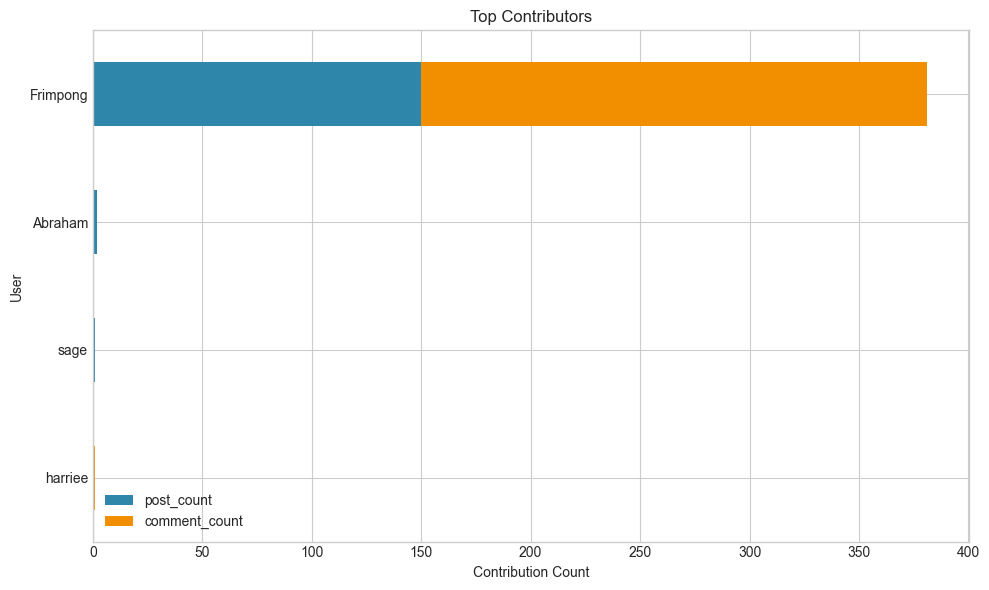

In [27]:
if top_contributors_df.empty:
    print('No top-contributor data returned for the selected range.')
else:
    plot_df = top_contributors_df.sort_values('total_contributions', ascending=True)
    ax = plot_df.plot(
        kind='barh',
        x='full_name',
        y=['post_count', 'comment_count'],
        stacked=True,
        figsize=(10, 6),
        color=['#2E86AB', '#F18F01'],
        title='Top Contributors',
    )
    ax.set_xlabel('Contribution Count')
    ax.set_ylabel('User')
    plt.tight_layout()
    plt.show()


## Activity Trends


In [28]:
activity_trends_df


,activity_date,posts_count,comments_count,total_activity_count
0,2026-02-11,2,0,2
1,2026-02-12,6,1,7
2,2026-02-13,6,2,8
3,2026-02-14,6,3,9
4,2026-02-15,2,1,3
5,2026-02-16,10,2,12
6,2026-02-17,6,2,8
7,2026-02-18,0,4,4
8,2026-02-19,4,3,7
9,2026-02-20,6,3,9


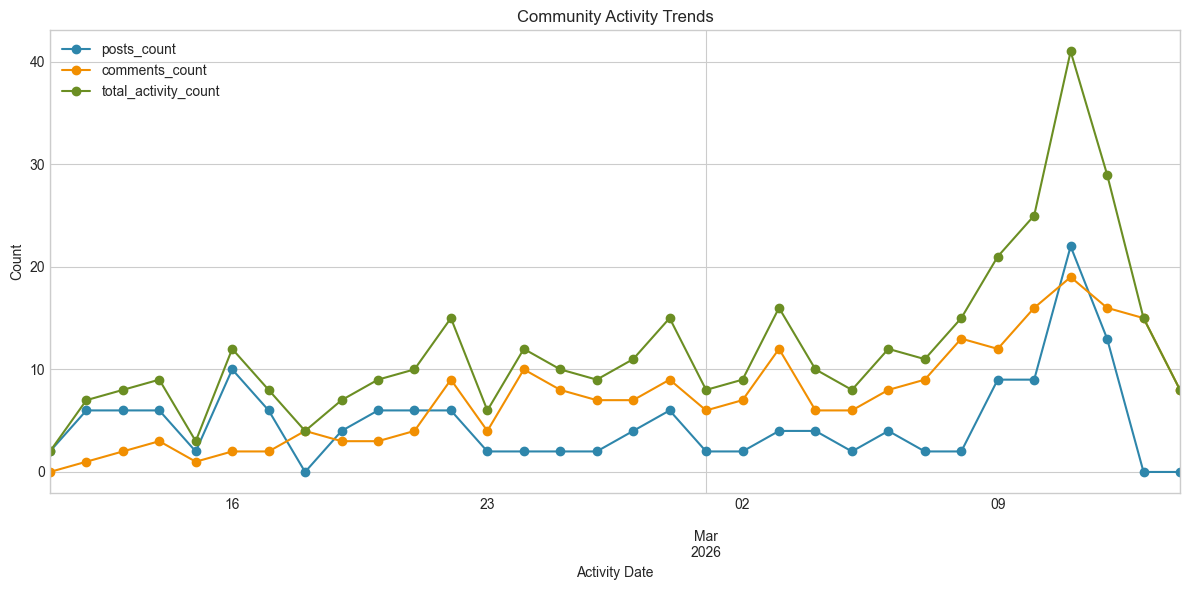

In [29]:
if activity_trends_df.empty:
    print('No activity-trend data returned for the selected range.')
else:
    ax = activity_trends_df.plot(
        x='activity_date',
        y=['posts_count', 'comments_count', 'total_activity_count'],
        figsize=(12, 6),
        marker='o',
        title='Community Activity Trends',
        color=['#2E86AB', '#F18F01', '#6B8E23'],
    )
    ax.set_xlabel('Activity Date')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


## Posts Per Category


In [30]:
posts_per_category_df


,category,posts_count
0,NEWS,46
1,DISCUSSION,43
2,EVENT,38
3,ALERT,26


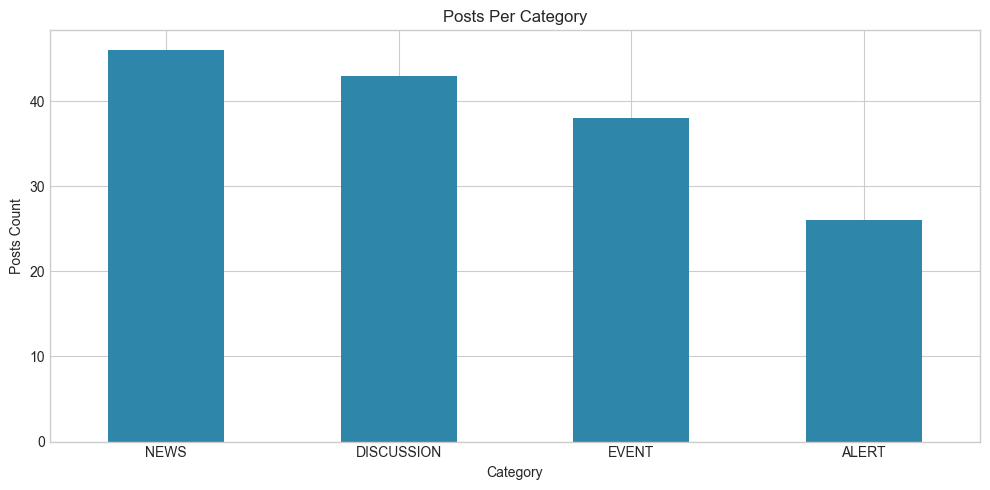

In [31]:
if posts_per_category_df.empty:
    print('No category data returned for the selected range.')
else:
    ax = posts_per_category_df.sort_values('posts_count', ascending=False).plot(
        kind='bar',
        x='category',
        y='posts_count',
        legend=False,
        figsize=(10, 5),
        color='#2E86AB',
        title='Posts Per Category',
    )
    ax.set_xlabel('Category')
    ax.set_ylabel('Posts Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
